# 📊 Causal Finance — ML & Causal Inference Training Pipeline

**A comprehensive notebook for training all ML models used by the Causal Finance platform.**

This notebook trains the following models on real market data:

| # | Model | Purpose | Library |
|---|-------|---------|--------|
| 1 | **Causal Discovery** | Discover causal structure (DAG) between macro factors & sectors | pgmpy, statsmodels |
| 2 | **Treatment Effects** | Estimate causal impact of macro changes on sectors | DoWhy, EconML |
| 3 | **Sensitivity Matrix** | Data-driven sector sensitivity coefficients | EconML (LinearDML) |
| 4 | **ARIMA** | Macro & return forecasting | statsmodels |
| 5 | **GARCH/EGARCH** | Volatility forecasting | arch |
| 6 | **LSTM** | Non-linear return prediction (GPU) | PyTorch |
| 7 | **Regime Detection** | Market regime classification (HMM) | hmmlearn |

### Output
All trained models are saved as `.pkl` files + `model_registry.json`, directly compatible
with the backend's `PredictionService` and `ModelRegistry`.

---

**Runtime:** Google Colab (GPU recommended for LSTM cells)

**Author:** Causal Finance Team | **Date:** February 2026

## 1. Setup & Installation

In [1]:
# ============================================
# INSTALL DEPENDENCIES (Colab)
# ============================================
# Uncomment for Google Colab:
!pip install -q yfinance fredapi dowhy econml pgmpy hmmlearn arch statsmodels torch scikit-learn joblib matplotlib seaborn networkx

import os
import sys
import json
import logging
import warnings
from datetime import datetime, timedelta
from typing import Dict, List, Optional, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('CausalFinance')

# Check GPU availability
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    DEVICE = torch.device('cuda' if GPU_AVAILABLE else 'cpu')
    print(f"PyTorch {torch.__version__} | GPU: {GPU_AVAILABLE} | Device: {DEVICE}")
    if GPU_AVAILABLE:
        print(f"  GPU Name: {torch.cuda.get_device_name(0)}")
except ImportError:
    GPU_AVAILABLE = False
    DEVICE = None
    print("PyTorch not available — LSTM training will use fallback")

# Dependency check
deps = {}
for lib in ['yfinance', 'fredapi', 'dowhy', 'econml', 'pgmpy', 'hmmlearn', 'arch', 'statsmodels', 'sklearn']:
    try:
        __import__(lib)
        deps[lib] = True
    except ImportError:
        deps[lib] = False
print("\nDependency check:")
for lib, avail in deps.items():
    print(f"  {'\u2705' if avail else '\u274c'} {lib}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 145.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 174.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.7 MB/s et

In [2]:
# ============================================
# CONFIGURATION
# ============================================

# === EDIT THESE SETTINGS ===
FRED_API_KEY = '695d4382c60535ca1a8bca93ecdadd93'  # Get free key at https://fred.stlouisfed.org/docs/api/api_key.html
START_DATE = '2018-01-01'     # Training data start (5+ years recommended)
END_DATE = None               # None = today
TRAIN_TEST_SPLIT = 0.85       # 85% train, 15% test

# === OUTPUT PATHS ===
# For Colab: models saved to /content/models/ then downloaded
# For local: set to your backend/data/models/ path
USE_COLAB = 'google.colab' in sys.modules

if USE_COLAB:
    OUTPUT_DIR = '/content/causal_finance_models'
else:
    # Local path — adjust to your project
    OUTPUT_DIR = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'backend', 'data'))

MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
PROCESSED_DIR = os.path.join(OUTPUT_DIR, 'processed')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Running on: {'Google Colab' if USE_COLAB else 'Local'}")

# Sector ETFs
SECTOR_ETFS = {
    'XLK': 'Technology',
    'XLV': 'Healthcare',
    'XLE': 'Energy',
    'XLF': 'Financials',
    'XLI': 'Industrials',
    'XLY': 'Consumer_Discretionary',
    'XLP': 'Consumer_Staples',
    'XLU': 'Utilities',
    'XLB': 'Materials',
    'XLRE': 'Real_Estate',
    'XLC': 'Communication_Services'
}

MARKET_TICKERS = {
    'SPY': 'SP500',
    '^VIX': 'VIX',
    '^TNX': 'Treasury_10Y',
    '^IRX': 'Treasury_3M',
}

# FRED Series (note: GOLDAMGBD228NLBM was discontinued — removed)
FRED_SERIES = {
    'FEDFUNDS': 'Fed_Funds_Rate',
    'CPIAUCSL': 'CPI',
    'GDP': 'GDP',
    'UNRATE': 'Unemployment_Rate',
    'DGS10': 'Treasury_10Y_Yield',
    'DGS2': 'Treasury_2Y_Yield',
    'T10Y2Y': 'Yield_Curve_Spread',
    'DCOILWTICO': 'Oil_WTI',
    'UMCSENT': 'Consumer_Sentiment',
    'INDPRO': 'Industrial_Production',
    'HOUST': 'Housing_Starts',
    'M2SL': 'M2_Money_Supply',
}

# Sensitivity matrix factor names (must match backend causal_service.py)
SENSITIVITY_FACTORS = ['interest_rates', 'inflation', 'gdp_growth', 'unemployment', 'vix', 'oil_price', 'dollar_index']
SENSITIVITY_SECTORS = ['technology', 'healthcare', 'energy', 'financials', 'industrials',
                       'consumer_discretionary', 'consumer_staples', 'utilities',
                       'materials', 'real_estate', 'communication_services']

# Mapping from FRED column names to sensitivity factor keys
MACRO_TO_FACTOR = {
    'Fed_Funds_Rate_Change': 'interest_rates',
    'CPI_Change': 'inflation',
    'GDP_Change': 'gdp_growth',
    'Unemployment_Rate_Change': 'unemployment',
    'VIX_Change': 'vix',
    'Oil_WTI_Change': 'oil_price',
    'Treasury_10Y_Yield_Change': 'interest_rates',  # alternative proxy
}

# Mapping from sector data column prefix to sensitivity sector keys
SECTOR_COL_TO_KEY = {
    'Technology': 'technology',
    'Healthcare': 'healthcare',
    'Energy': 'energy',
    'Financials': 'financials',
    'Industrials': 'industrials',
    'Consumer_Discretionary': 'consumer_discretionary',
    'Consumer_Staples': 'consumer_staples',
    'Utilities': 'utilities',
    'Materials': 'materials',
    'Real_Estate': 'real_estate',
    'Communication_Services': 'communication_services'
}

Output directory: /content/causal_finance_models
Models directory: /content/causal_finance_models/models
Running on: Google Colab


## 2. Data Acquisition

Fetch 5+ years of:
- **11 sector ETFs** (XLK, XLV, XLE, ...) via yfinance
- **Market indices** (SPY, VIX, Treasury yields) via yfinance
- **13 macro series** (Fed Rate, CPI, GDP, ...) via FRED API

In [3]:
import yfinance as yf

# ============================================
# 2a. Fetch Sector ETF Data
# ============================================
print("Fetching sector ETF data...")
end_date = END_DATE or datetime.now().strftime('%Y-%m-%d')

etf_tickers = list(SECTOR_ETFS.keys())
etf_data = yf.download(etf_tickers, start=START_DATE, end=end_date, progress=True)

# Build sector price DataFrame (Close prices)
sector_prices = pd.DataFrame()
for ticker, sector_name in SECTOR_ETFS.items():
    try:
        if isinstance(etf_data.columns, pd.MultiIndex):
            sector_prices[sector_name] = etf_data['Close'][ticker]
        else:
            sector_prices[sector_name] = etf_data['Close']
    except Exception as e:
        print(f"  Warning: {ticker} ({sector_name}) - {e}")

print(f"Sector prices: {sector_prices.shape}")
print(f"Date range: {sector_prices.index[0]} to {sector_prices.index[-1]}")
print(f"Sectors: {list(sector_prices.columns)}")

# ============================================
# 2b. Fetch Market Indices
# ============================================
print("\nFetching market indices...")
market_data = pd.DataFrame()
for ticker, name in MARKET_TICKERS.items():
    try:
        d = yf.download(ticker, start=START_DATE, end=end_date, progress=False)
        if not d.empty:
            if isinstance(d.columns, pd.MultiIndex):
                market_data[name] = d['Close'][ticker] if ticker in d['Close'].columns else d['Close'].iloc[:, 0]
            else:
                market_data[name] = d['Close']
    except Exception as e:
        print(f"  Warning: {ticker} ({name}) - {e}")

print(f"Market data: {market_data.shape} — columns: {list(market_data.columns)}")

# ============================================
# 2c. Fetch FRED Macroeconomic Data
# ============================================
print("\nFetching FRED macro data...")
macro_data = pd.DataFrame()

if FRED_API_KEY:
    from fredapi import Fred
    fred = Fred(api_key=FRED_API_KEY)

    for series_id, name in FRED_SERIES.items():
        try:
            s = fred.get_series(series_id, observation_start=START_DATE, observation_end=end_date)
            if s is not None and len(s) > 0:
                macro_data[name] = s
                print(f"  \u2705 {name}: {len(s)} observations")
        except Exception as e:
            print(f"  \u274c {name}: {e}")
else:
    print("  No FRED_API_KEY — generating synthetic macro data")
    dates = pd.date_range(start=START_DATE, end=end_date, freq='D')
    n = len(dates)
    np.random.seed(42)
    macro_data = pd.DataFrame({
        'Fed_Funds_Rate': np.cumsum(np.random.randn(n) * 0.01) + 2.0,
        'CPI': np.cumsum(np.random.randn(n) * 0.05) + 250,
        'GDP': np.cumsum(np.random.randn(n) * 50) + 20000,
        'Unemployment_Rate': np.clip(np.cumsum(np.random.randn(n) * 0.02) + 5.0, 3, 15),
        'Treasury_10Y_Yield': np.clip(np.cumsum(np.random.randn(n) * 0.01) + 3.0, 0.5, 8),
        'Treasury_2Y_Yield': np.clip(np.cumsum(np.random.randn(n) * 0.01) + 2.5, 0.2, 7),
        'Oil_WTI': np.clip(np.cumsum(np.random.randn(n) * 0.5) + 60, 20, 150),
        'Consumer_Sentiment': np.clip(np.cumsum(np.random.randn(n) * 0.5) + 80, 50, 120),
    }, index=dates)
    macro_data['Yield_Curve_Spread'] = macro_data['Treasury_10Y_Yield'] - macro_data['Treasury_2Y_Yield']

print(f"\nMacro data: {macro_data.shape} — columns: {list(macro_data.columns)}")

Fetching sector ETF data...


[*********************100%***********************]  11 of 11 completed


Sector prices: (2050, 11)
Date range: 2018-01-02 00:00:00 to 2026-02-27 00:00:00
Sectors: ['Technology', 'Healthcare', 'Energy', 'Financials', 'Industrials', 'Consumer_Discretionary', 'Consumer_Staples', 'Utilities', 'Materials', 'Real_Estate', 'Communication_Services']

Fetching market indices...
Market data: (2050, 4) — columns: ['SP500', 'VIX', 'Treasury_10Y', 'Treasury_3M']

Fetching FRED macro data...
  ✅ Fed_Funds_Rate: 97 observations
  ✅ CPI: 97 observations
  ✅ GDP: 32 observations
  ✅ Unemployment_Rate: 97 observations
  ✅ Treasury_10Y_Yield: 2129 observations
  ✅ Treasury_2Y_Yield: 2129 observations
  ✅ Yield_Curve_Spread: 2130 observations
  ✅ Oil_WTI: 2126 observations
  ✅ Consumer_Sentiment: 97 observations
  ✅ Industrial_Production: 97 observations
  ✅ Housing_Starts: 96 observations
  ✅ M2_Money_Supply: 97 observations

Macro data: (97, 12) — columns: ['Fed_Funds_Rate', 'CPI', 'GDP', 'Unemployment_Rate', 'Treasury_10Y_Yield', 'Treasury_2Y_Yield', 'Yield_Curve_Spread', '

## 3. Feature Engineering

Build the unified feature matrix combining:
- Multi-horizon sector returns (1d, 5d, 21d, 63d)
- Rolling volatility (21d, 63d)
- Technical indicators (SMA, RSI, MACD, Bollinger Bands)
- Macro rate-of-change features
- Market regime features (VIX, yield curve)

In [4]:
# ============================================
# 3. FEATURE ENGINEERING
# ============================================

features = pd.DataFrame(index=sector_prices.index)

# --- Sector Returns (multi-horizon) ---
for sector in sector_prices.columns:
    prices = sector_prices[sector]
    for period in [1, 5, 21, 63]:
        features[f'{sector}_Return_{period}d'] = np.log(prices / prices.shift(period))
    # Rolling volatility
    ret_1d = features[f'{sector}_Return_1d']
    features[f'{sector}_Volatility_21d'] = ret_1d.rolling(21).std() * np.sqrt(252)
    features[f'{sector}_Volatility_63d'] = ret_1d.rolling(63).std() * np.sqrt(252)
    # Technical indicators
    features[f'{sector}_SMA_50'] = prices.rolling(50).mean()
    features[f'{sector}_SMA_200'] = prices.rolling(200).mean()
    features[f'{sector}_RSI_14'] = 100 - (100 / (1 + (prices.diff().clip(lower=0).rolling(14).mean() / (-prices.diff().clip(upper=0)).rolling(14).mean())))
    ema12 = prices.ewm(span=12).mean()
    ema26 = prices.ewm(span=26).mean()
    features[f'{sector}_MACD'] = ema12 - ema26
    sma20 = prices.rolling(20).mean()
    std20 = prices.rolling(20).std()
    features[f'{sector}_BB_Width'] = (4 * std20) / sma20
    features[f'{sector}_Momentum_21d'] = prices / prices.shift(21) - 1

# --- Market features ---
if 'SP500' in market_data.columns:
    features['SP500_Return'] = np.log(market_data['SP500'] / market_data['SP500'].shift(1))
    features['SP500_Volatility_21d'] = features['SP500_Return'].rolling(21).std() * np.sqrt(252)
    features['SP500_SMA_50'] = market_data['SP500'].rolling(50).mean()
    features['SP500_SMA_200'] = market_data['SP500'].rolling(200).mean()

if 'VIX' in market_data.columns:
    features['VIX'] = market_data['VIX']
    features['VIX_Change'] = market_data['VIX'].pct_change()
    features['VIX_MA_10'] = market_data['VIX'].rolling(10).mean()
    features['VIX_Regime'] = pd.cut(market_data['VIX'], bins=[0, 15, 20, 30, 100], labels=[0, 1, 2, 3]).astype(float)

# --- Macro features ---
macro_daily = macro_data.resample('D').ffill().reindex(features.index, method='ffill')
for col in macro_data.columns:
    if col in macro_daily.columns:
        features[col] = macro_daily[col]
        features[f'{col}_Change'] = macro_daily[col].pct_change()
        features[f'{col}_Change_21d'] = macro_daily[col].pct_change(periods=21)

# --- Yield curve slope ---
if 'Treasury_10Y_Yield' in features.columns and 'Treasury_2Y_Yield' in features.columns:
    features['Yield_Curve_Spread'] = features['Treasury_10Y_Yield'] - features['Treasury_2Y_Yield']
    features['Yield_Curve_Inverted'] = (features['Yield_Curve_Spread'] < 0).astype(float)

# --- Clean up ---
features = features.replace([np.inf, -np.inf], np.nan)
features = features.ffill().bfill()
features = features.dropna()

print(f"Feature matrix shape: {features.shape}")
print(f"Date range: {features.index[0]} \u2192 {features.index[-1]}")
print(f"Total features: {len(features.columns)}")

# Save feature matrix
features.to_parquet(os.path.join(PROCESSED_DIR, 'feature_matrix.parquet'))
print(f"\n\u2705 Saved feature_matrix.parquet ({features.shape[0]} rows \u00d7 {features.shape[1]} cols)")

Feature matrix shape: (2050, 177)
Date range: 2018-01-02 00:00:00 → 2026-02-27 00:00:00
Total features: 177

✅ Saved feature_matrix.parquet (2050 rows × 177 cols)


In [5]:
# ============================================
# TRAIN / TEST SPLIT (time-series safe)
# ============================================
split_idx = int(len(features) * TRAIN_TEST_SPLIT)
train_data = features.iloc[:split_idx].copy()
test_data = features.iloc[split_idx:].copy()

print(f"Train: {train_data.shape} ({train_data.index[0]} \u2192 {train_data.index[-1]})")
print(f"Test:  {test_data.shape}  ({test_data.index[0]} \u2192 {test_data.index[-1]})")

# Identify column groups
sector_return_cols = [c for c in features.columns if c.endswith('_Return_1d') and not c.startswith('SP500')]
macro_change_cols = [c for c in features.columns if c.endswith('_Change') and not c.endswith('_Change_21d')]

print(f"\nSector return columns ({len(sector_return_cols)}): {sector_return_cols}")
print(f"Macro change columns ({len(macro_change_cols)}): {macro_change_cols}")

Train: (1742, 177) (2018-01-02 00:00:00 → 2024-12-03 00:00:00)
Test:  (308, 177)  (2024-12-04 00:00:00 → 2026-02-27 00:00:00)

Sector return columns (11): ['Technology_Return_1d', 'Healthcare_Return_1d', 'Energy_Return_1d', 'Financials_Return_1d', 'Industrials_Return_1d', 'Consumer_Discretionary_Return_1d', 'Consumer_Staples_Return_1d', 'Utilities_Return_1d', 'Materials_Return_1d', 'Real_Estate_Return_1d', 'Communication_Services_Return_1d']
Macro change columns (13): ['VIX_Change', 'Fed_Funds_Rate_Change', 'CPI_Change', 'GDP_Change', 'Unemployment_Rate_Change', 'Treasury_10Y_Yield_Change', 'Treasury_2Y_Yield_Change', 'Yield_Curve_Spread_Change', 'Oil_WTI_Change', 'Consumer_Sentiment_Change', 'Industrial_Production_Change', 'Housing_Starts_Change', 'M2_Money_Supply_Change']


## 4. Exploratory Data Analysis

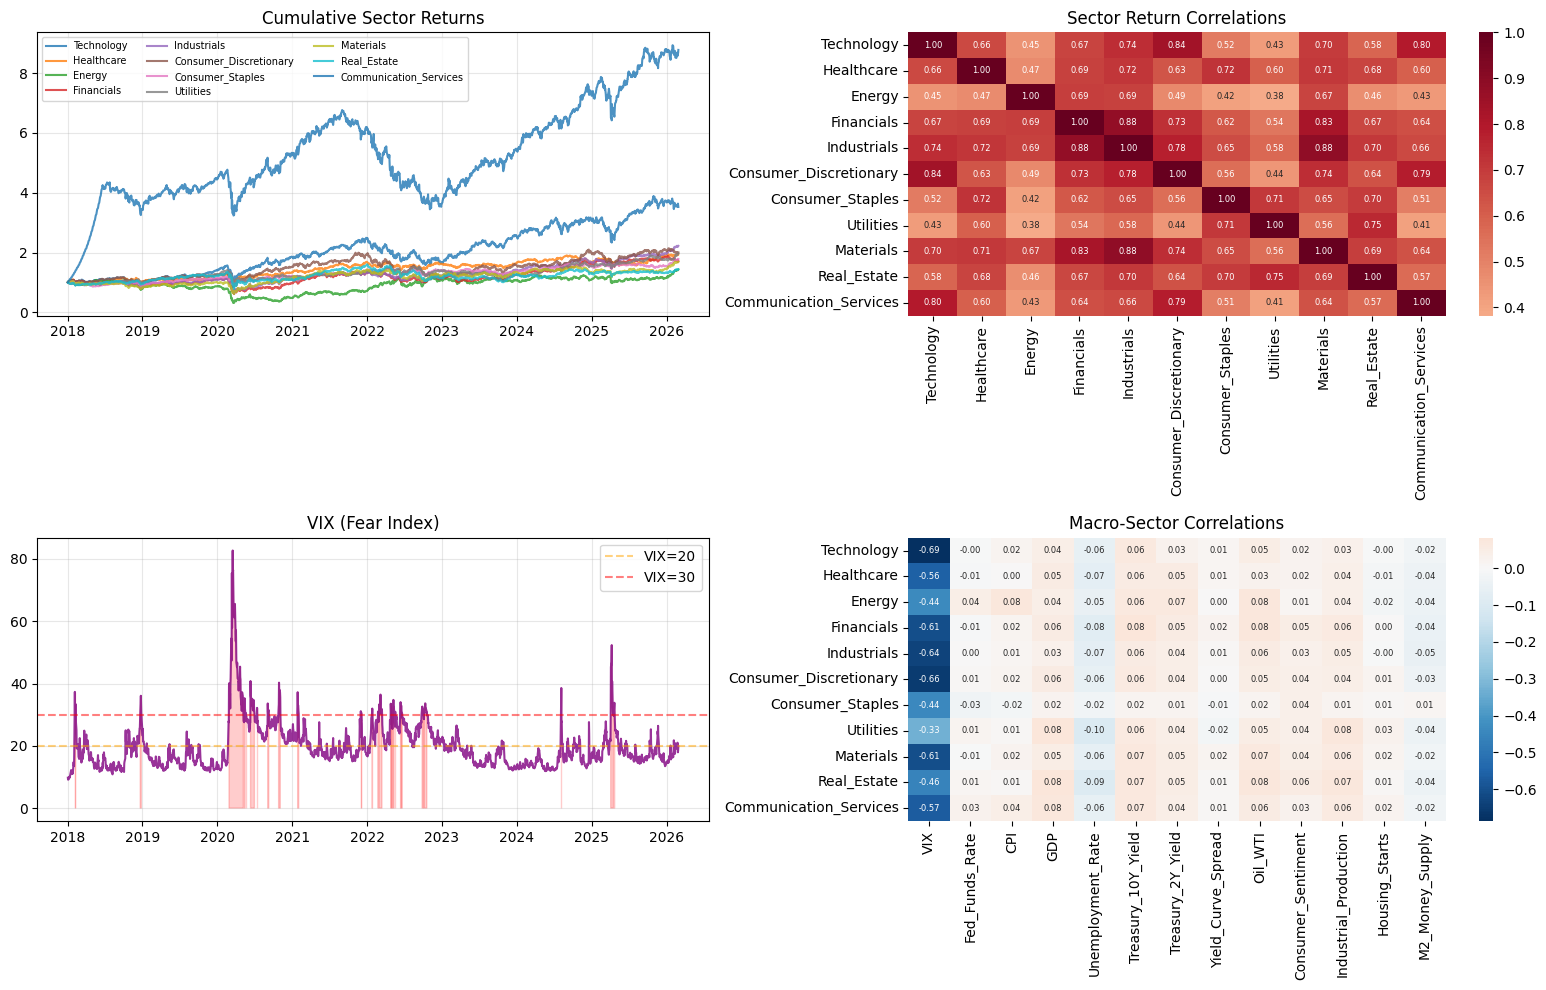

✅ EDA complete


In [6]:
# ============================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 4a. Sector cumulative returns
ax = axes[0, 0]
for col in sector_return_cols:
    sector_name = col.replace('_Return_1d', '')
    cumret = (1 + features[col]).cumprod()
    ax.plot(cumret, label=sector_name, alpha=0.8)
ax.set_title('Cumulative Sector Returns')
ax.legend(fontsize=7, ncol=3)
ax.grid(True, alpha=0.3)

# 4b. Sector correlation heatmap
ax = axes[0, 1]
corr = features[sector_return_cols].corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            xticklabels=[c.replace('_Return_1d', '') for c in sector_return_cols],
            yticklabels=[c.replace('_Return_1d', '') for c in sector_return_cols],
            annot_kws={'size': 6})
ax.set_title('Sector Return Correlations')

# 4c. VIX over time
ax = axes[1, 0]
if 'VIX' in features.columns:
    ax.plot(features['VIX'], color='purple', alpha=0.8)
    ax.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='VIX=20')
    ax.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='VIX=30')
    ax.fill_between(features.index, 0, features['VIX'], where=features['VIX'] > 30, alpha=0.2, color='red')
    ax.set_title('VIX (Fear Index)')
    ax.legend()
    ax.grid(True, alpha=0.3)

# 4d. Macro-sector cross-correlation
ax = axes[1, 1]
available_macro = [c for c in macro_change_cols if c in features.columns]
if available_macro and sector_return_cols:
    cross_corr = features[sector_return_cols + available_macro].corr()
    macro_sector_corr = cross_corr.loc[sector_return_cols, available_macro]
    sns.heatmap(macro_sector_corr, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                xticklabels=[c.replace('_Change', '') for c in available_macro],
                yticklabels=[c.replace('_Return_1d', '') for c in sector_return_cols],
                annot_kws={'size': 6})
    ax.set_title('Macro-Sector Correlations')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 EDA complete")

## 5. Causal Discovery

Discover the causal structure between macro factors and sector returns using:
1. **Granger Causality** — Does lagged X predict Y beyond Y's own lags?
2. **PC Algorithm** — Constraint-based DAG learning from conditional independence tests
3. **Transfer Entropy** — Information-theoretic measure of directed information flow

Combine all three into a **consensus causal graph** with confidence scores.

In [7]:
from statsmodels.tsa.stattools import grangercausalitytests
import networkx as nx

# ============================================
# 5a. GRANGER CAUSALITY MATRIX
# ============================================
print("Running Granger Causality tests...")

# Select columns for causal analysis
causal_cols = sector_return_cols.copy()
# Add available macro changes
for mc in macro_change_cols:
    if mc in train_data.columns and train_data[mc].dropna().std() > 1e-10:
        causal_cols.append(mc)
if 'VIX_Change' in train_data.columns:
    causal_cols.append('VIX_Change') if 'VIX_Change' not in causal_cols else None
if 'SP500_Return' in train_data.columns:
    causal_cols.append('SP500_Return') if 'SP500_Return' not in causal_cols else None

# Remove duplicates
causal_cols = list(dict.fromkeys(causal_cols))

MAX_LAG = 5
SIGNIFICANCE = 0.05

granger_results = {}
causal_series = train_data[causal_cols].dropna()

for target in sector_return_cols:  # Only test sectors as outcomes
    granger_results[target] = {}
    for cause in causal_cols:
        if cause == target:
            continue
        try:
            test_df = causal_series[[target, cause]].dropna()
            if len(test_df) < MAX_LAG * 3:
                continue
            result = grangercausalitytests(test_df, maxlag=MAX_LAG, verbose=False)
            # Get minimum p-value across all lags
            min_p = min(result[lag][0]['ssr_ftest'][1] for lag in range(1, MAX_LAG + 1))
            best_lag = min(range(1, MAX_LAG + 1), key=lambda l: result[l][0]['ssr_ftest'][1])
            granger_results[target][cause] = {
                'p_value': min_p,
                'significant': min_p < SIGNIFICANCE,
                'best_lag': best_lag,
                'f_stat': result[best_lag][0]['ssr_ftest'][0]
            }
        except Exception as e:
            pass  # Skip failed tests

# Count significant relationships
sig_count = sum(1 for target in granger_results for cause in granger_results[target]
                if granger_results[target][cause].get('significant', False))
total_tests = sum(len(v) for v in granger_results.values())
print(f"Granger: {sig_count}/{total_tests} significant relationships (p < {SIGNIFICANCE})")

Running Granger Causality tests...
Granger: 176/264 significant relationships (p < 0.05)


In [8]:
# ============================================
# 5b. PC ALGORITHM (pgmpy)
# ============================================
print("Running PC Algorithm for DAG structure learning...")

pc_edges = []
try:
    from pgmpy.estimators import PC

    # Use subset for tractability (select top correlated macro + all sectors)
    pc_cols = sector_return_cols[:6]  # Top 6 sectors
    pc_macro = [c for c in macro_change_cols if c in train_data.columns][:4]  # Top 4 macro
    pc_all = pc_cols + pc_macro

    pc_data = train_data[pc_all].dropna()

    # Discretize for PC algorithm (required for pgmpy)
    pc_discrete = pc_data.copy()
    for col in pc_discrete.columns:
        pc_discrete[col] = pd.qcut(pc_discrete[col], q=5, labels=False, duplicates='drop')

    pc_estimator = PC(pc_discrete)
    dag = pc_estimator.estimate(significance_level=0.01, return_type='dag')

    pc_edges = list(dag.edges())
    print(f"PC Algorithm found {len(pc_edges)} directed edges:")
    for edge in pc_edges:
        print(f"  {edge[0]} \u2192 {edge[1]}")
except Exception as e:
    print(f"PC Algorithm failed: {e}")
    print("Continuing with Granger results only.")

Running PC Algorithm for DAG structure learning...


  0%|          | 0/5 [00:00<?, ?it/s]

PC Algorithm found 12 directed edges:
  Technology_Return_1d → Healthcare_Return_1d
  Technology_Return_1d → Consumer_Discretionary_Return_1d
  Healthcare_Return_1d → Industrials_Return_1d
  Energy_Return_1d → Industrials_Return_1d
  Energy_Return_1d → Financials_Return_1d
  Industrials_Return_1d → Financials_Return_1d
  Consumer_Discretionary_Return_1d → Industrials_Return_1d
  VIX_Change → Consumer_Discretionary_Return_1d
  VIX_Change → Technology_Return_1d
  CPI_Change → GDP_Change
  Fed_Funds_Rate_Change → GDP_Change
  Fed_Funds_Rate_Change → CPI_Change


Consensus DAG: 24 nodes, 182 edges


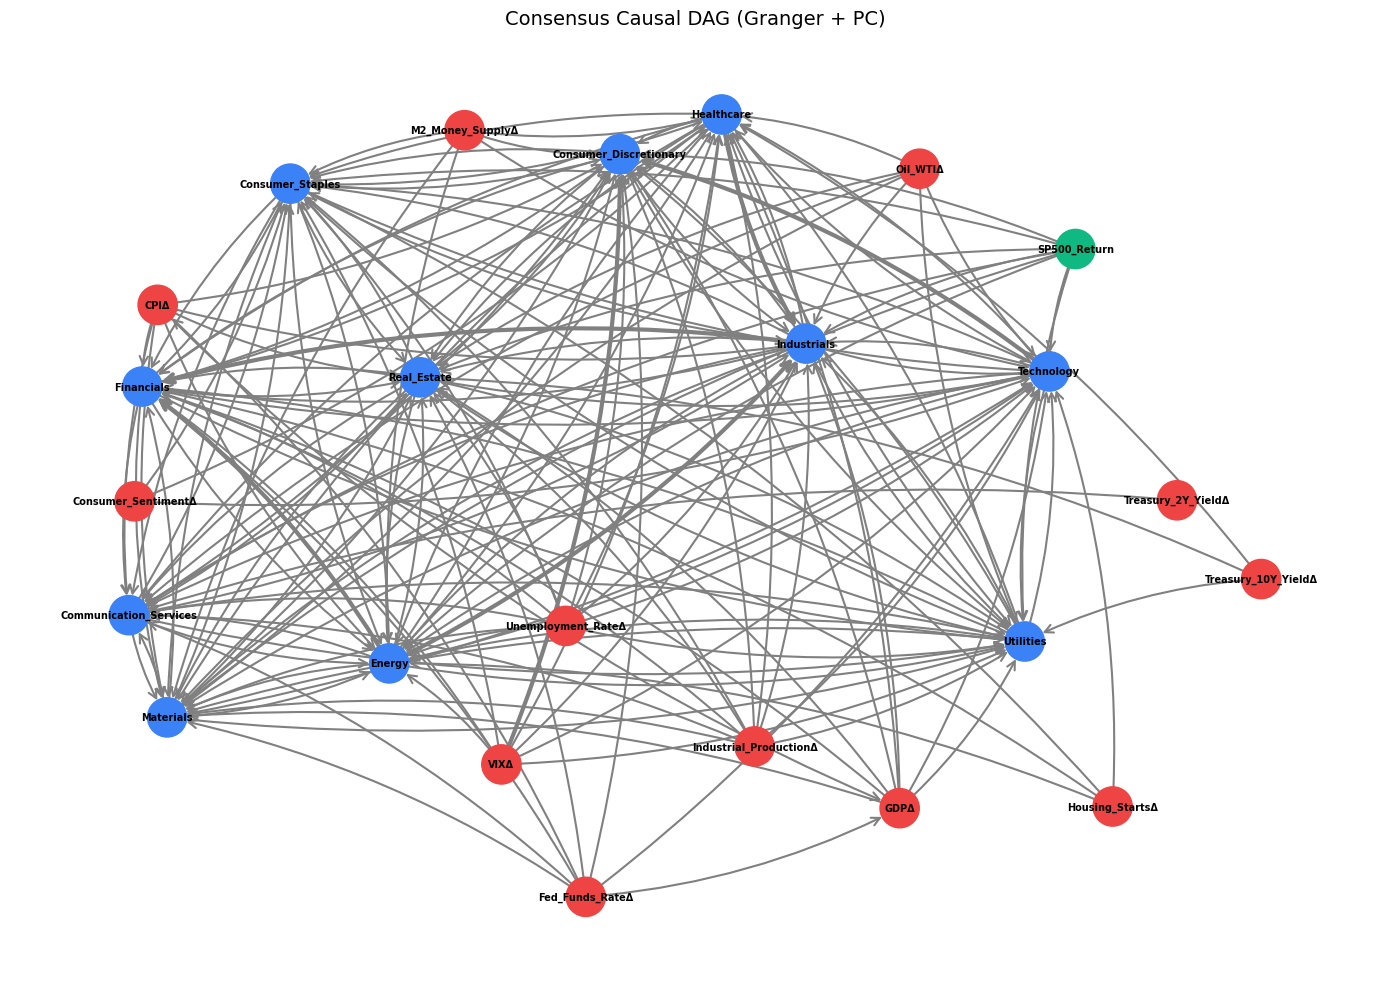


✅ Saved causal discovery model: /content/causal_finance_models/models/causal_discovery_20260228_133628.pkl


In [9]:
# ============================================
# 5c. CONSENSUS DAG & VISUALIZATION
# ============================================

# Build consensus graph combining Granger + PC
consensus_edges = []
edge_confidence = {}

# Add Granger edges
for target in granger_results:
    for cause, info in granger_results[target].items():
        if info.get('significant', False):
            edge = (cause, target)
            consensus_edges.append(edge)
            edge_confidence[edge] = edge_confidence.get(edge, 0) + 1

# Add PC edges (extra confidence)
for edge in pc_edges:
    if edge not in edge_confidence:
        consensus_edges.append(edge)
    edge_confidence[edge] = edge_confidence.get(edge, 0) + 1

# Normalize confidence (max = number of methods that agree)
max_conf = max(edge_confidence.values()) if edge_confidence else 1
for edge in edge_confidence:
    edge_confidence[edge] /= max_conf

# Build NetworkX DAG
G = nx.DiGraph()
for edge, conf in edge_confidence.items():
    if conf >= 0.5:  # Only keep edges with >= 50% method agreement
        G.add_edge(edge[0], edge[1], weight=conf)

print(f"Consensus DAG: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Color nodes by type
node_colors = []
for node in G.nodes():
    if node in sector_return_cols:
        node_colors.append('#3B82F6')  # Blue for sectors
    elif node in macro_change_cols:
        node_colors.append('#EF4444')  # Red for macro
    else:
        node_colors.append('#10B981')  # Green for market

# Layout
pos = nx.spring_layout(G, seed=42, k=2)
edge_weights = [G[u][v]['weight'] * 3 for u, v in G.edges()]

# Short labels
labels = {n: n.replace('_Return_1d', '').replace('_Change', '\u0394') for n in G.nodes()}

nx.draw(G, pos, ax=ax, labels=labels, node_color=node_colors,
        node_size=800, font_size=7, font_weight='bold',
        edge_color='gray', width=edge_weights, arrows=True,
        arrowsize=15, arrowstyle='->', connectionstyle='arc3,rad=0.1')

ax.set_title('Consensus Causal DAG (Granger + PC)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'causal_dag.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save causal discovery results
VERSION = datetime.now().strftime('%Y%m%d_%H%M%S')
causal_discovery_results = {
    'granger_matrix': granger_results,
    'pc_edges': pc_edges,
    'consensus_edges': list(edge_confidence.keys()),
    'edge_confidence': {str(k): v for k, v in edge_confidence.items()},
    'dag': {
        'nodes': [{'id': n, 'type': 'sector' if n in sector_return_cols else 'macro'} for n in G.nodes()],
        'edges': [{'from': u, 'to': v, 'weight': G[u][v]['weight']} for u, v in G.edges()]
    }
}

causal_path = os.path.join(MODELS_DIR, f'causal_discovery_{VERSION}.pkl')
joblib.dump(causal_discovery_results, causal_path)
print(f"\n\u2705 Saved causal discovery model: {causal_path}")

## 6. Treatment Effect Estimation

For each (macro_factor, sector) pair identified by causal discovery:
1. **DoWhy** backdoor adjustment — full causal inference framework
2. **EconML LinearDML** — Double Machine Learning for ATE
3. **EconML CausalForestDML** — Heterogeneous treatment effects (CATE)
4. **OLS** fallback — simple regression with controls

Output: A **data-driven sensitivity matrix** replacing hardcoded coefficients.

In [10]:
# ============================================
# 6. TREATMENT EFFECT ESTIMATION
# ============================================
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from scipy import stats as sp_stats

# Check available libraries
DOWHY_OK = False
ECONML_OK = False
try:
    from dowhy import CausalModel
    DOWHY_OK = True
    print("\u2705 DoWhy available")
except ImportError:
    print("\u26a0\ufe0f DoWhy not available — will use OLS fallback")

try:
    from econml.dml import LinearDML, CausalForestDML
    ECONML_OK = True
    print("\u2705 EconML available")
except ImportError:
    print("\u26a0\ufe0f EconML not available — will use OLS fallback")


def estimate_ate_multi_method(data, treatment_col, outcome_col, confounder_cols):
    """
    Estimate ATE using multiple methods, return best estimate.
    Priority: DoWhy > DML > OLS
    """
    analysis_data = data[[treatment_col, outcome_col] + confounder_cols].dropna()
    if len(analysis_data) < 100:
        return {'ate': 0.0, 'method': 'insufficient_data', 'p_value': 1.0}

    results = []

    # Method 1: DoWhy backdoor
    if DOWHY_OK:
        try:
            model = CausalModel(
                data=analysis_data,
                treatment=treatment_col,
                outcome=outcome_col,
                common_causes=confounder_cols
            )
            estimand = model.identify_effect(proceed_when_unidentifiable=True)
            estimate = model.estimate_effect(
                estimand,
                method_name='backdoor.linear_regression',
                confidence_intervals=True
            )
            results.append({
                'ate': float(estimate.value),
                'method': 'dowhy_backdoor',
                'ci_lower': float(estimate.get_confidence_intervals()[0]) if estimate.get_confidence_intervals() else None,
                'ci_upper': float(estimate.get_confidence_intervals()[1]) if estimate.get_confidence_intervals() else None,
            })
        except Exception as e:
            pass  # Fall through to next method

    # Method 2: EconML DML
    if ECONML_OK:
        try:
            Y = analysis_data[outcome_col].values
            T = analysis_data[treatment_col].values
            X = analysis_data[confounder_cols].values

            dml = LinearDML(
                model_y=RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42),
                model_t=RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42),
                random_state=42, cv=3
            )
            dml.fit(Y, T, X=X)
            ate = float(dml.ate())
            ci = dml.ate_interval(alpha=0.05)
            results.append({
                'ate': ate,
                'method': 'linear_dml',
                'ci_lower': float(ci[0]),
                'ci_upper': float(ci[1]),
            })
        except Exception as e:
            pass

    # Method 3: OLS with confounders (always available)
    try:
        Y = analysis_data[outcome_col].values
        X_ols = analysis_data[[treatment_col] + confounder_cols].values
        model = LinearRegression()
        model.fit(X_ols, Y)
        ate_ols = float(model.coef_[0])

        # Bootstrap CI
        boot_ates = []
        for _ in range(500):
            idx = np.random.choice(len(Y), size=len(Y), replace=True)
            m = LinearRegression().fit(X_ols[idx], Y[idx])
            boot_ates.append(m.coef_[0])
        ci_l, ci_u = np.percentile(boot_ates, [2.5, 97.5])
        se = np.std(boot_ates)
        t_stat = ate_ols / se if se > 0 else 0
        p_val = 2 * (1 - sp_stats.t.cdf(abs(t_stat), df=len(Y) - len(confounder_cols) - 2))

        results.append({
            'ate': ate_ols,
            'method': 'ols',
            'ci_lower': float(ci_l),
            'ci_upper': float(ci_u),
            'p_value': float(p_val),
            'standard_error': float(se)
        })
    except Exception as e:
        pass

    if not results:
        return {'ate': 0.0, 'method': 'failed', 'p_value': 1.0}

    # Return best result (prioritize DoWhy > DML > OLS)
    best = results[0]
    best['all_methods'] = results
    best['treatment'] = treatment_col
    best['outcome'] = outcome_col
    best['sample_size'] = len(analysis_data)
    return best


print("\nEstimating treatment effects for all macro \u2192 sector pairs...")
print("="*70)

# Define confounders (other macro variables + market)
base_confounders = []
if 'SP500_Return' in train_data.columns:
    base_confounders.append('SP500_Return')
if 'SP500_Volatility_21d' in train_data.columns:
    base_confounders.append('SP500_Volatility_21d')
if 'VIX' in train_data.columns:
    base_confounders.append('VIX')

# All macro treatments
treatments = [c for c in macro_change_cols if c in train_data.columns and train_data[c].dropna().std() > 1e-10]
print(f"Treatments: {treatments}")
print(f"Confounders: {base_confounders}")
print(f"Outcomes: {sector_return_cols}")
print()

# Estimate all effects
effects_matrix = []
n_pairs = len(treatments) * len(sector_return_cols)
i = 0

for outcome_col in sector_return_cols:
    for treatment_col in treatments:
        i += 1
        # Use other macro variables as additional confounders
        confounders = base_confounders + [t for t in treatments if t != treatment_col and t in train_data.columns]
        confounders = list(set(confounders))  # deduplicate
        # Remove if same as treatment or outcome
        confounders = [c for c in confounders if c != treatment_col and c != outcome_col]

        effect = estimate_ate_multi_method(train_data, treatment_col, outcome_col, confounders)
        effect['treatment'] = treatment_col
        effect['outcome'] = outcome_col
        effects_matrix.append(effect)

        if i % 20 == 0 or i == n_pairs:
            print(f"  Progress: {i}/{n_pairs} pairs estimated")

print(f"\n\u2705 Estimated {len(effects_matrix)} treatment effects")

# Display summary
sig_effects = [e for e in effects_matrix if abs(e.get('ate', 0)) > 0.01]
print(f"Significant effects (|ATE| > 0.01): {len(sig_effects)}")
for e in sorted(sig_effects, key=lambda x: abs(x.get('ate', 0)), reverse=True)[:10]:
    print(f"  {e['treatment']:30s} \u2192 {e['outcome']:30s}: ATE = {e['ate']:+.4f} ({e['method']})")

✅ DoWhy available


✅ EconML available

Estimating treatment effects for all macro → sector pairs...
Treatments: ['VIX_Change', 'Fed_Funds_Rate_Change', 'CPI_Change', 'GDP_Change', 'Unemployment_Rate_Change', 'Treasury_10Y_Yield_Change', 'Treasury_2Y_Yield_Change', 'Yield_Curve_Spread_Change', 'Oil_WTI_Change', 'Consumer_Sentiment_Change', 'Industrial_Production_Change', 'Housing_Starts_Change', 'M2_Money_Supply_Change']
Confounders: ['SP500_Return', 'SP500_Volatility_21d', 'VIX']
Outcomes: ['Technology_Return_1d', 'Healthcare_Return_1d', 'Energy_Return_1d', 'Financials_Return_1d', 'Industrials_Return_1d', 'Consumer_Discretionary_Return_1d', 'Consumer_Staples_Return_1d', 'Utilities_Return_1d', 'Materials_Return_1d', 'Real_Estate_Return_1d', 'Communication_Services_Return_1d']



  Progress: 20/143 pairs estimated


  Progress: 40/143 pairs estimated


  Progress: 60/143 pairs estimated


  Progress: 80/143 pairs estimated


  Progress: 100/143 pairs estimated


  Progress: 120/143 pairs estimated


  Progress: 140/143 pairs estimated


  Progress: 143/143 pairs estimated

✅ Estimated 143 treatment effects
Significant effects (|ATE| > 0.01): 67
  CPI_Change                     → Energy_Return_1d              : ATE = +1.5794 (ols)
  CPI_Change                     → Utilities_Return_1d           : ATE = -0.8562 (ols)
  CPI_Change                     → Real_Estate_Return_1d         : ATE = -0.7300 (ols)
  CPI_Change                     → Consumer_Staples_Return_1d    : ATE = -0.6573 (ols)
  M2_Money_Supply_Change         → Energy_Return_1d              : ATE = -0.3749 (ols)
  M2_Money_Supply_Change         → Consumer_Staples_Return_1d    : ATE = +0.2526 (ols)
  M2_Money_Supply_Change         → Utilities_Return_1d           : ATE = +0.2422 (ols)
  CPI_Change                     → Industrials_Return_1d         : ATE = +0.2197 (ols)
  CPI_Change                     → Consumer_Discretionary_Return_1d: ATE = -0.2152 (ols)
  GDP_Change                     → Industrials_Return_1d         : ATE = -0.1764 (ols)


Building data-driven sensitivity matrix...


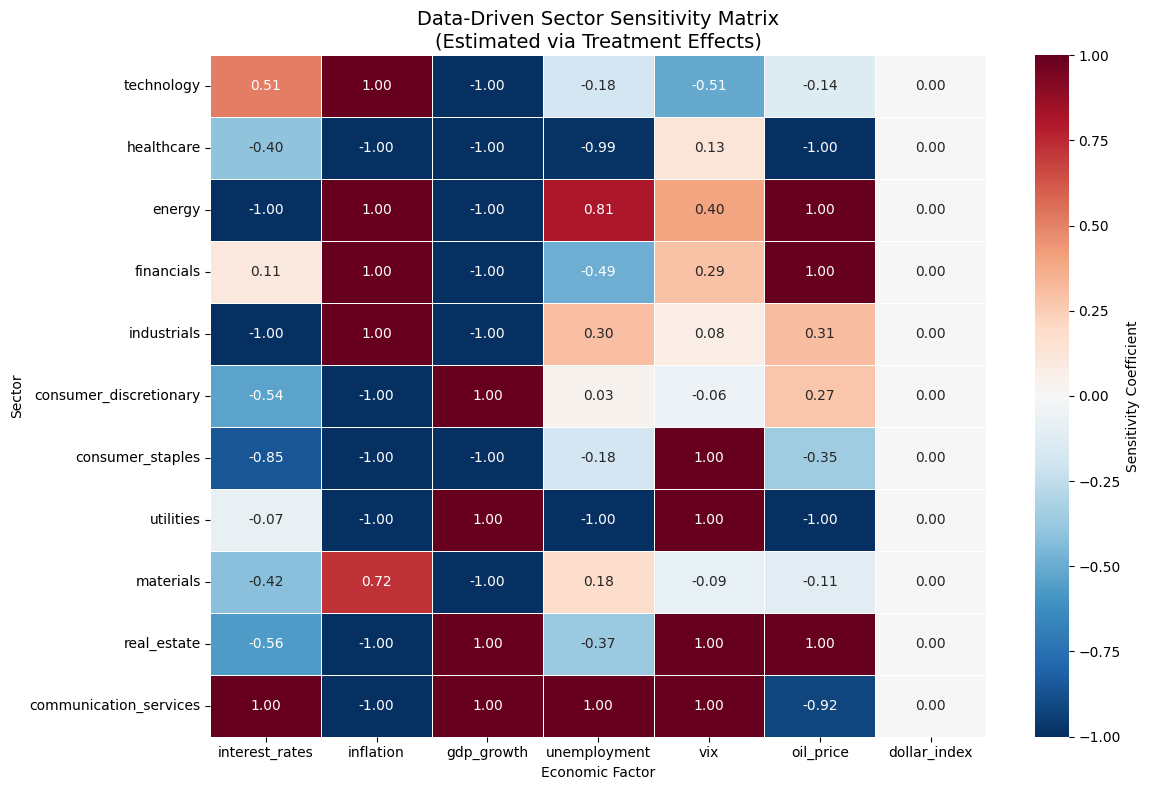


Sensitivity Matrix:
                        interest_rates  inflation  gdp_growth  unemployment    vix  oil_price  dollar_index
technology                       0.512      1.000        -1.0        -0.185 -0.512     -0.138           0.0
healthcare                      -0.403     -1.000        -1.0        -0.992  0.132     -1.000           0.0
energy                          -1.000      1.000        -1.0         0.814  0.404      1.000           0.0
financials                       0.107      1.000        -1.0        -0.486  0.294      1.000           0.0
industrials                     -1.000      1.000        -1.0         0.300  0.076      0.308           0.0
consumer_discretionary          -0.537     -1.000         1.0         0.034 -0.056      0.274           0.0
consumer_staples                -0.855     -1.000        -1.0        -0.185  1.000     -0.355           0.0
utilities                       -0.072     -1.000         1.0        -1.000  1.000     -1.000           0.0
materia

In [11]:
# ============================================
# 6b. BUILD SENSITIVITY MATRIX
# ============================================
# Convert estimated effects into the exact format expected by
# backend/app/services/causal_service.py: Dict[str, Dict[str, float]]
# Keys: 11 sector names, 7 factor names

print("Building data-driven sensitivity matrix...")

sensitivity_matrix = {}

for sector_col_prefix, sector_key in SECTOR_COL_TO_KEY.items():
    outcome_col = f'{sector_col_prefix}_Return_1d'
    if outcome_col not in sector_return_cols:
        # Initialize with zeros
        sensitivity_matrix[sector_key] = {f: 0.0 for f in SENSITIVITY_FACTORS}
        continue

    sector_effects = {}
    for effect in effects_matrix:
        if effect['outcome'] == outcome_col:
            treatment = effect['treatment']
            # Map treatment column to factor key
            factor_key = MACRO_TO_FACTOR.get(treatment)
            if factor_key and factor_key in SENSITIVITY_FACTORS:
                ate = effect.get('ate', 0.0)
                # Normalize ATE to reasonable range [-1, 1]
                # The raw ATE is in return units per 1-unit change in macro
                # Scale to match the existing coefficient range
                normalized_ate = np.clip(ate * 100, -1.0, 1.0)  # Scale up and clip
                sector_effects[factor_key] = round(float(normalized_ate), 3)

    # Fill missing factors with 0
    for f in SENSITIVITY_FACTORS:
        if f not in sector_effects:
            sector_effects[f] = 0.0
    sensitivity_matrix[sector_key] = sector_effects

# Display as heatmap
sm_df = pd.DataFrame(sensitivity_matrix).T
sm_df = sm_df[SENSITIVITY_FACTORS]  # Ensure column order

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(sm_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sensitivity Coefficient'})
ax.set_title('Data-Driven Sector Sensitivity Matrix\n(Estimated via Treatment Effects)', fontsize=14)
ax.set_ylabel('Sector')
ax.set_xlabel('Economic Factor')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sensitivity_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nSensitivity Matrix:")
print(sm_df.to_string())

# Save treatment effects + sensitivity matrix
treatment_path = os.path.join(MODELS_DIR, f'treatment_effects_{VERSION}.pkl')
joblib.dump({
    'effects_matrix': effects_matrix,
    'sensitivity_matrix': sensitivity_matrix,  # Dict[str, Dict[str, float]]
}, treatment_path)
print(f"\n\u2705 Saved treatment effects: {treatment_path}")

## 7. Forecasting Models

Train ARIMA and GARCH models for each sector:
- **ARIMA** — Auto-order selection via AIC grid search for return/level forecasting
- **GARCH/EGARCH** — Volatility forecasting with leverage effects

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

# ============================================
# 7. ARIMA + GARCH FORECASTING
# ============================================
print("Training ARIMA + GARCH models for each sector...\n")

forecast_results = {}
forecast_evaluations = {}

for sector_col in sector_return_cols:
    sector_name = sector_col.replace('_Return_1d', '')
    print(f"--- {sector_name} ---")

    train_series = train_data[sector_col].dropna()
    test_series = test_data[sector_col].dropna()

    if len(train_series) < 252:
        print(f"  Skipping (insufficient data: {len(train_series)} < 252)")
        continue

    forecast_results[sector_name] = {}
    forecast_evaluations[sector_name] = {}

    # === ARIMA ===
    try:
        # Auto order selection via AIC
        best_aic = np.inf
        best_order = (1, 0, 1)

        for p in range(0, 4):
            for d in range(0, 2):
                for q in range(0, 4):
                    try:
                        model = ARIMA(train_series, order=(p, d, q))
                        fit = model.fit()
                        if fit.aic < best_aic:
                            best_aic = fit.aic
                            best_order = (p, d, q)
                    except:
                        continue

        # Fit with best order
        arima_model = ARIMA(train_series, order=best_order)
        arima_fit = arima_model.fit()

        # Forecast
        n_test = min(len(test_series), 63)
        arima_forecast = arima_fit.forecast(steps=n_test)

        # Evaluate
        arima_rmse = np.sqrt(np.mean((test_series.values[:n_test] - arima_forecast.values[:n_test])**2))
        arima_mae = np.mean(np.abs(test_series.values[:n_test] - arima_forecast.values[:n_test]))

        # Save model
        arima_path = os.path.join(MODELS_DIR, f'arima_{sector_name}_{VERSION}.pkl')
        joblib.dump({
            'model': arima_fit,
            'order': best_order,
            'aic': best_aic,
            'sector': sector_name,
        }, arima_path)

        forecast_results[sector_name]['arima'] = arima_path
        forecast_evaluations[sector_name]['arima'] = {
            'rmse': float(arima_rmse),
            'mae': float(arima_mae),
            'order': best_order,
            'aic': float(best_aic)
        }
        print(f"  ARIMA{best_order}: RMSE={arima_rmse:.6f}, MAE={arima_mae:.6f}, AIC={best_aic:.1f}")
    except Exception as e:
        print(f"  ARIMA failed: {e}")

    # === GARCH ===
    try:
        # Scale returns for GARCH (arch library expects ~percentage returns)
        returns_scaled = train_series * 100

        # Try EGARCH first, fall back to standard GARCH
        vol_model_used = None
        garch_fit = None
        for vol_model in ['EGARCH', 'GARCH']:
            try:
                garch = arch_model(returns_scaled, vol=vol_model, p=1, q=1, mean='AR', lags=1)
                garch_fit = garch.fit(disp='off')
                vol_model_used = vol_model
                break
            except:
                continue

        if garch_fit is None:
            raise ValueError("Both EGARCH and GARCH fitting failed")

        # Forecast volatility — use simulation for multi-step (EGARCH doesn't support analytic horizon > 1)
        forecast_horizon = min(n_test, 21)
        try:
            # Try analytic first (faster, works for standard GARCH)
            garch_forecast = garch_fit.forecast(horizon=forecast_horizon)
            vol_forecast = np.sqrt(garch_forecast.variance.dropna().values[-1]) / 100
        except Exception:
            try:
                # Fall back to simulation-based forecast (works for all vol models)
                garch_forecast = garch_fit.forecast(horizon=forecast_horizon, method='simulation', simulations=1000)
                vol_forecast = np.sqrt(garch_forecast.variance.dropna().values[-1]) / 100
            except Exception:
                # Last resort: single-step analytic forecast
                garch_forecast = garch_fit.forecast(horizon=1)
                vol_forecast = np.sqrt(garch_forecast.variance.dropna().values[-1]) / 100

        # Save
        garch_path = os.path.join(MODELS_DIR, f'garch_{sector_name}_{VERSION}.pkl')
        joblib.dump({
            'model': garch_fit,
            'vol_type': vol_model_used,
            'sector': sector_name,
            'params': dict(garch_fit.params),
        }, garch_path)

        forecast_results[sector_name]['garch'] = garch_path
        forecast_evaluations[sector_name]['garch'] = {
            'vol_type': vol_model_used,
            'mean_vol_forecast': float(np.mean(vol_forecast)),
            'aic': float(garch_fit.aic),
            'bic': float(garch_fit.bic),
        }
        print(f"  {vol_model_used}(1,1): Mean Vol={np.mean(vol_forecast):.4f}, AIC={garch_fit.aic:.1f}")
    except Exception as e:
        print(f"  GARCH failed: {e}")

print(f"\n✅ Trained forecasting models for {len(forecast_results)} sectors")

Training ARIMA + GARCH models for each sector...

--- Technology ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  ARIMA(2, 1, 3): RMSE=0.015576, MAE=0.012024, AIC=-9426.6
  EGARCH(1,1): Mean Vol=0.0128, AIC=6143.8
--- Healthcare ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  ARIMA(3, 1, 2): RMSE=0.008079, MAE=0.006617, AIC=-10790.3
  EGARCH(1,1): Mean Vol=0.0087, AIC=4675.0
--- Energy ---


...

  ARIMA(2, 1, 3): RMSE=0.010032, MAE=0.007913, AIC=-9964.4
  EGARCH(1,1): Mean Vol=0.0100, AIC=5567.9
--- Real_Estate ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  ARIMA(2, 0, 3): RMSE=0.011160, MAE=0.008408, AIC=-9907.7
  EGARCH(1,1): Mean Vol=0.0119, AIC=5474.6
--- Communication_Services ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  ARIMA(3, 1, 3): RMSE=0.009662, MAE=0.007438, AIC=-9874.4
  EGARCH(1,1): Mean Vol=0.0103, AIC=5750.5

✅ Trained forecasting models for 11 sectors


## 8. LSTM Forecasting (GPU-accelerated)

Train a 2-layer LSTM with MC Dropout for uncertainty quantification.
Uses all available features as input for non-linear return prediction.

**Note:** This cell benefits from GPU. On CPU it will take longer but still works.

In [13]:
# ============================================
# 8. LSTM FORECASTING
# ============================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

SEQUENCE_LENGTH = 60
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001
PATIENCE = 10

class LSTMModel(nn.Module):
    """2-layer LSTM with MC dropout for uncertainty."""
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        return self.fc(out)


def prepare_lstm_data(data, target_col, feature_cols, seq_len=60):
    """Prepare sequences for LSTM training."""
    features = data[feature_cols].values
    target = data[target_col].values

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(features_scaled[i:i+seq_len])
        y.append(target[i+seq_len])

    return np.array(X), np.array(y), scaler


# Select a compact feature set for LSTM
lstm_feature_cols = []
for col in sector_return_cols:
    lstm_feature_cols.append(col)
vol_cols = [c for c in features.columns if 'Volatility_21d' in c]
lstm_feature_cols.extend(vol_cols[:6])
if 'SP500_Return' in features.columns:
    lstm_feature_cols.append('SP500_Return')
if 'VIX' in features.columns:
    lstm_feature_cols.append('VIX')
if 'VIX_Change' in features.columns:
    lstm_feature_cols.append('VIX_Change')

# Remove duplicates, keep only available
lstm_feature_cols = list(dict.fromkeys(c for c in lstm_feature_cols if c in train_data.columns))
print(f"LSTM features: {len(lstm_feature_cols)} columns")
print(f"Device: {DEVICE}")

# Train LSTM for top sectors
lstm_sectors = sector_return_cols[:5]  # Top 5 sectors

for target_col in lstm_sectors:
    sector_name = target_col.replace('_Return_1d', '')
    print(f"\n--- LSTM: {sector_name} ---")

    # Prepare data
    X_train, y_train, scaler = prepare_lstm_data(train_data, target_col, lstm_feature_cols, SEQUENCE_LENGTH)
    X_test, y_test, _ = prepare_lstm_data(test_data, target_col, lstm_feature_cols, SEQUENCE_LENGTH)

    if len(X_train) < 100:
        print(f"  Skipping (insufficient sequences: {len(X_train)})")
        continue

    input_size = X_train.shape[2]

    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(DEVICE)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

    # Split train into train/val
    val_size = int(len(X_train_t) * 0.15)
    X_val_t = X_train_t[-val_size:]
    y_val_t = y_train_t[-val_size:]
    X_train_t = X_train_t[:-val_size]
    y_train_t = y_train_t[:-val_size]

    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # Build model
    model = LSTMModel(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    # Training loop
    best_val_loss = np.inf
    patience_counter = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_loss = epoch_loss / len(train_loader)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Load best model
    if best_state is not None:
        model.load_state_dict(best_state)

    # Test evaluation
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t).cpu().numpy().flatten()

    test_rmse = np.sqrt(np.mean((y_test[:len(test_pred)] - test_pred)**2))

    # MC Dropout for uncertainty
    model.train()  # Enable dropout
    mc_preds = []
    for _ in range(50):
        with torch.no_grad():
            mc_pred = model(X_test_t).cpu().numpy().flatten()
            mc_preds.append(mc_pred)
    mc_preds = np.array(mc_preds)
    uncertainty = np.std(mc_preds, axis=0).mean()

    print(f"  Test RMSE: {test_rmse:.6f} | Uncertainty: {uncertainty:.6f}")

    # Save model — include input_size for reload!
    lstm_path = os.path.join(MODELS_DIR, f'lstm_{sector_name}_{VERSION}.pkl')
    torch.save({
        'model_state': model.cpu().state_dict(),
        'scaler': scaler,
        'config': {
            'input_size': input_size,  # CRITICAL: needed for model reconstruction
            'hidden_size': HIDDEN_SIZE,
            'num_layers': NUM_LAYERS,
            'dropout': DROPOUT,
            'sequence_length': SEQUENCE_LENGTH,
        },
        'feature_cols': lstm_feature_cols,
        'metrics': {
            'test_rmse': float(test_rmse),
            'best_val_loss': float(best_val_loss),
            'uncertainty': float(uncertainty),
        }
    }, lstm_path)

    if sector_name not in forecast_results:
        forecast_results[sector_name] = {}
    if sector_name not in forecast_evaluations:
        forecast_evaluations[sector_name] = {}
    forecast_results[sector_name]['lstm'] = lstm_path
    forecast_evaluations[sector_name]['lstm'] = {
        'test_rmse': float(test_rmse),
        'uncertainty': float(uncertainty),
    }

print(f"\n\u2705 LSTM training complete")

LSTM features: 20 columns
Device: cpu

--- LSTM: Technology ---
  Early stopping at epoch 19
  Test RMSE: 0.017379 | Uncertainty: 0.004287

--- LSTM: Healthcare ---
  Early stopping at epoch 12
  Test RMSE: 0.010907 | Uncertainty: 0.003728

--- LSTM: Energy ---
  Early stopping at epoch 19
  Test RMSE: 0.016615 | Uncertainty: 0.004424

--- LSTM: Financials ---
  Epoch  20 | Train Loss: 0.000215 | Val Loss: 0.000086
  Early stopping at epoch 21
  Test RMSE: 0.012603 | Uncertainty: 0.003745

--- LSTM: Industrials ---
  Epoch  20 | Train Loss: 0.000192 | Val Loss: 0.000076
  Early stopping at epoch 26
  Test RMSE: 0.012795 | Uncertainty: 0.003599

✅ LSTM training complete


## 9. Regime Detection (Hidden Markov Model)

Train a 4-state Gaussian HMM to classify market regimes:
- **Bull** — Positive returns, low volatility
- **Sideways** — Near-zero returns, moderate volatility
- **Bear** — Negative returns, elevated volatility
- **Crisis** — Sharp declines, extreme volatility

Training Hidden Markov Model for regime detection...



Regime Statistics:
Regime       Label        Mean Ret   Mean Vol   Mean VIX     Days    Pct
----------------------------------------------------------------------
0            bull           0.0010     0.1053      15.08      910  52.2%
2            sideways       0.0001     0.2047      23.77      784  45.0%
1            bear          -0.0016     0.6252      48.47       48   2.8%
3            crisis            N/A        N/A        N/A        0   0.0%

Transition Matrix:
           bull  sideways   bear  crisis
bull      0.988     0.012  0.000     0.0
sideways  0.014     0.985  0.002     0.0
bear      0.000     0.029  0.971     0.0
crisis    1.000     0.000  0.000     0.0


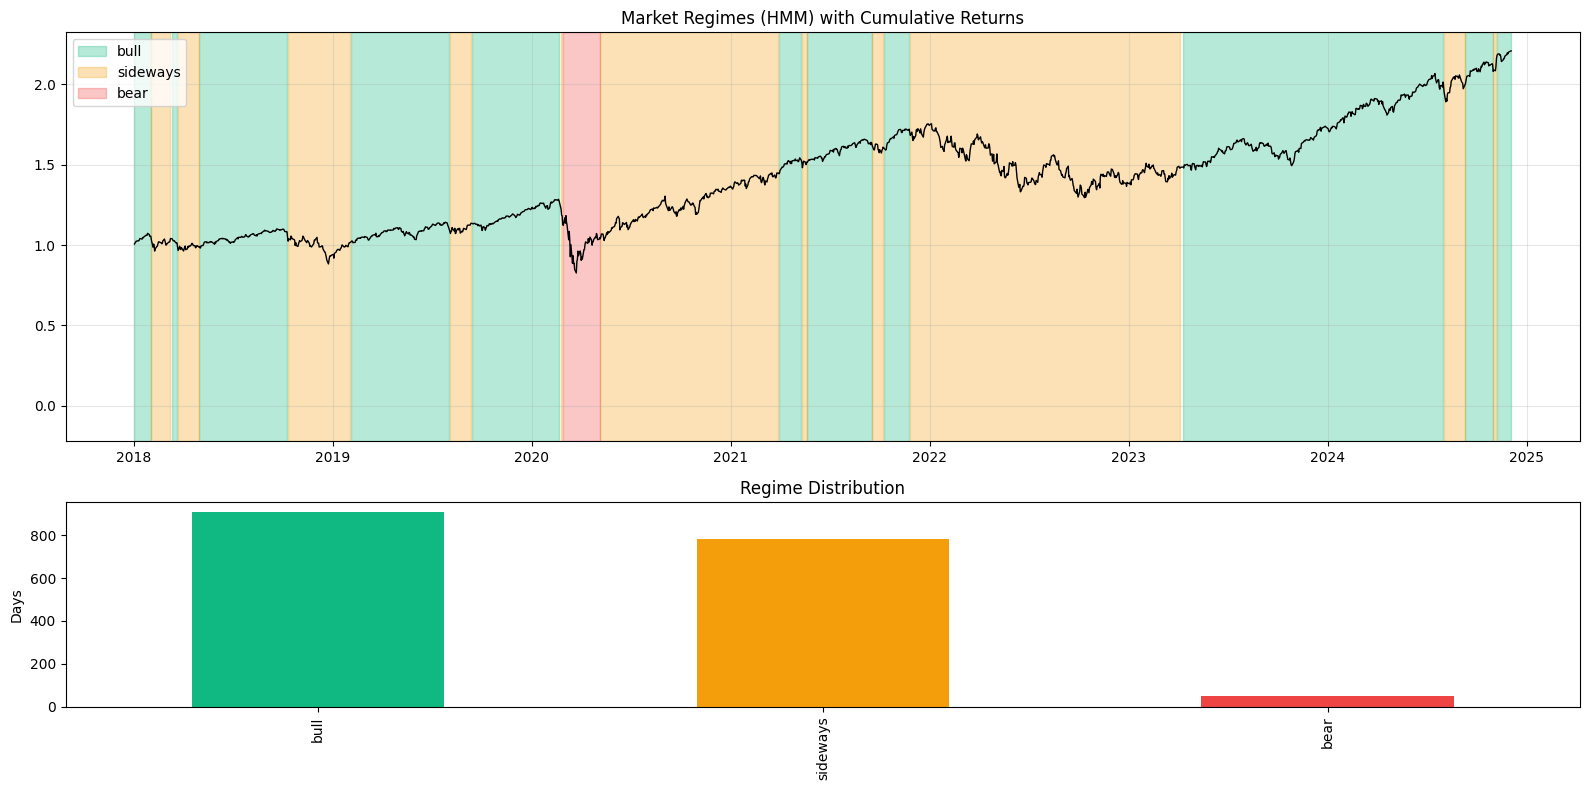


✅ Saved regime detector: /content/causal_finance_models/models/regime_detector_20260228_133628.pkl


In [14]:
from hmmlearn.hmm import GaussianHMM

# ============================================
# 9. REGIME DETECTION (HMM)
# ============================================
print("Training Hidden Markov Model for regime detection...\n")

N_REGIMES = 4

# Prepare features: returns, volatility, VIX
regime_features = pd.DataFrame(index=train_data.index)

if 'SP500_Return' in train_data.columns:
    regime_features['returns'] = train_data['SP500_Return']
else:
    # Average sector returns as proxy
    regime_features['returns'] = train_data[sector_return_cols].mean(axis=1)

if 'SP500_Volatility_21d' in train_data.columns:
    regime_features['volatility'] = train_data['SP500_Volatility_21d']
else:
    regime_features['volatility'] = regime_features['returns'].rolling(21).std() * np.sqrt(252)

if 'VIX' in train_data.columns:
    regime_features['vix'] = train_data['VIX']
else:
    regime_features['vix'] = regime_features['volatility'] * 100  # Rough proxy

regime_features = regime_features.dropna()
X_regime = regime_features.values

# Fit HMM
hmm = GaussianHMM(
    n_components=N_REGIMES,
    covariance_type='full',
    n_iter=200,
    random_state=42,
    tol=1e-4
)
hmm.fit(X_regime)

# Predict regimes
regimes = hmm.predict(X_regime)

# Label regimes by their mean returns (bull = highest, crisis = lowest)
regime_stats = {}
for r in range(N_REGIMES):
    mask = regimes == r
    if mask.sum() > 0:
        regime_stats[r] = {
            'mean_return': float(regime_features['returns'][mask].mean()),
            'mean_vol': float(regime_features['volatility'][mask].mean()),
            'mean_vix': float(regime_features['vix'][mask].mean()),
            'count': int(mask.sum()),
            'pct': round(mask.sum() / len(regimes) * 100, 1)
        }
    else:
        regime_stats[r] = {
            'mean_return': 0.0,
            'mean_vol': 0.0,
            'mean_vix': 0.0,
            'count': 0,
            'pct': 0.0
        }

# Sort regimes by mean return (descending) — only those with data
regimes_with_data = [r for r in range(N_REGIMES) if regime_stats[r]['count'] > 0]
regimes_without_data = [r for r in range(N_REGIMES) if regime_stats[r]['count'] == 0]

regime_order = sorted(regimes_with_data, key=lambda r: regime_stats[r]['mean_return'], reverse=True)
regime_order.extend(regimes_without_data)  # Append empty regimes at the end

ALL_LABELS = ['bull', 'sideways', 'bear', 'crisis']
REGIME_LABELS = {}
for i, r in enumerate(regime_order):
    REGIME_LABELS[r] = ALL_LABELS[i] if i < len(ALL_LABELS) else f'regime_{i}'
REGIME_COLORS = {'bull': '#10B981', 'sideways': '#F59E0B', 'bear': '#EF4444', 'crisis': '#7C3AED'}

print("Regime Statistics:")
print(f"{'Regime':<12} {'Label':<10} {'Mean Ret':>10} {'Mean Vol':>10} {'Mean VIX':>10} {'Days':>8} {'Pct':>6}")
print("-" * 70)
for r in regime_order:
    s = regime_stats[r]
    label = REGIME_LABELS[r]
    if s['count'] > 0:
        print(f"{r:<12} {label:<10} {s['mean_return']:>10.4f} {s['mean_vol']:>10.4f} {s['mean_vix']:>10.2f} {s['count']:>8} {s['pct']:>5.1f}%")
    else:
        print(f"{r:<12} {label:<10} {'N/A':>10} {'N/A':>10} {'N/A':>10} {0:>8} {0.0:>5.1f}%")

# Transition matrix
print(f"\nTransition Matrix:")
trans_mat = hmm.transmat_
labels = [REGIME_LABELS[r] for r in regime_order]
trans_df = pd.DataFrame(trans_mat[regime_order][:, regime_order], index=labels, columns=labels)
print(trans_df.round(3).to_string())

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})

# Regime timeline
ax = axes[0]
regime_series = pd.Series(regimes, index=regime_features.index)
for r, label in REGIME_LABELS.items():
    mask = regime_series == r
    if mask.any():
        ax.fill_between(regime_features.index, 0, 1, where=mask, alpha=0.3,
                       color=REGIME_COLORS.get(label, '#999999'), label=label,
                       transform=ax.get_xaxis_transform())

cumret = (1 + regime_features['returns']).cumprod()
ax.plot(cumret, color='black', linewidth=1)
ax.set_title('Market Regimes (HMM) with Cumulative Returns')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Regime distribution — use reindex to handle missing labels gracefully
ax = axes[1]
regime_named = regime_series.map(REGIME_LABELS)
active_labels = [l for l in ALL_LABELS if l in regime_named.values]
if active_labels:
    counts = regime_named.value_counts().reindex(active_labels, fill_value=0)
    colors = [REGIME_COLORS.get(l, '#999999') for l in active_labels]
    counts.plot.bar(ax=ax, color=colors)
else:
    ax.text(0.5, 0.5, 'No regimes detected', ha='center', va='center', transform=ax.transAxes)
ax.set_title('Regime Distribution')
ax.set_ylabel('Days')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'regime_detection.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save regime model
regime_path = os.path.join(MODELS_DIR, f'regime_detector_{VERSION}.pkl')
joblib.dump({
    'model': hmm,
    'regime_labels': REGIME_LABELS,
    'regime_stats': regime_stats,
    'transition_matrix': trans_mat.tolist(),
    'feature_names': list(regime_features.columns),
    'n_regimes': N_REGIMES,
}, regime_path)
print(f"\n✅ Saved regime detector: {regime_path}")

## 10. Model Registry & Export

Create `model_registry.json` in the exact format expected by the backend's
`ModelRegistry` class, with all 4 active model types registered.

In [15]:
# ============================================
# 10. MODEL REGISTRY
# ============================================
print("Building model registry...\n")

registry = {
    'models': {},
    'active_versions': {}
}

# --- Causal Discovery ---
try:
    causal_model_id = f'causal_discovery_engine_{VERSION}'
    registry['models'][causal_model_id] = {
        'type': 'causal',
        'name': 'discovery_engine',
        'version': VERSION,
        'filepath': causal_path,
        'metrics': {
            'n_relationships': G.number_of_edges(),
            'n_nodes': G.number_of_nodes(),
            'granger_significant': sig_count,
            'pc_edges': len(pc_edges),
        },
        'hyperparameters': {'max_lag': MAX_LAG, 'significance': SIGNIFICANCE},
        'registered_at': datetime.now().isoformat(),
    }
    registry['active_versions']['causal'] = causal_model_id
    print(f"  ✅ Causal: {causal_model_id}")
except NameError as e:
    print(f"  ⚠️ Causal model skipped (missing variable: {e})")

# --- Treatment Effects ---
try:
    treatment_model_id = f'treatment_effect_estimator_{VERSION}'
    registry['models'][treatment_model_id] = {
        'type': 'treatment',
        'name': 'effect_estimator',
        'version': VERSION,
        'filepath': treatment_path,
        'metrics': {
            'n_effects': len(effects_matrix),
            'n_significant': len(sig_effects),
            'methods_used': list(set(e.get('method', 'unknown') for e in effects_matrix)),
        },
        'hyperparameters': {'method': 'auto (DoWhy > DML > OLS)'},
        'registered_at': datetime.now().isoformat(),
    }
    registry['active_versions']['treatment'] = treatment_model_id
    print(f"  ✅ Treatment: {treatment_model_id}")
except NameError as e:
    print(f"  ⚠️ Treatment model skipped (missing variable: {e})")

# --- Forecasting Ensemble ---
try:
    forecast_model_id = f'forecast_ensemble_{VERSION}'
    registry['models'][forecast_model_id] = {
        'type': 'forecast',
        'name': 'ensemble',
        'version': VERSION,
        'filepath': MODELS_DIR,  # Directory containing sector-specific models
        'metrics': forecast_evaluations,
        'hyperparameters': {'models': ['arima', 'garch', 'lstm']},
        'registered_at': datetime.now().isoformat(),
    }
    registry['active_versions']['forecast'] = forecast_model_id
    print(f"  ✅ Forecast: {forecast_model_id}")
except NameError as e:
    print(f"  ⚠️ Forecast model skipped (missing variable: {e})")

# --- Regime Detection ---
try:
    regime_model_id = f'regime_hmm_detector_{VERSION}'
    registry['models'][regime_model_id] = {
        'type': 'regime',
        'name': 'hmm_detector',
        'version': VERSION,
        'filepath': regime_path,
        'metrics': regime_stats,
        'hyperparameters': {'n_regimes': N_REGIMES, 'covariance_type': 'full'},
        'registered_at': datetime.now().isoformat(),
    }
    registry['active_versions']['regime'] = regime_model_id
    print(f"  ✅ Regime: {regime_model_id}")
except NameError as e:
    print(f"  ⚠️ Regime model skipped (missing variable: {e})")

# Save registry
registry_path = os.path.join(MODELS_DIR, 'model_registry.json')
with open(registry_path, 'w') as f:
    json.dump(registry, f, indent=2, default=str)

print(f"\nModel Registry:")
print(f"  Total models: {len(registry['models'])}")
print(f"  Active versions:")
for model_type, model_id in registry['active_versions'].items():
    print(f"    {model_type}: {model_id}")
print(f"\n✅ Saved registry: {registry_path}")

Building model registry...

  ✅ Causal: causal_discovery_engine_20260228_133628
  ✅ Treatment: treatment_effect_estimator_20260228_133628
  ✅ Forecast: forecast_ensemble_20260228_133628
  ✅ Regime: regime_hmm_detector_20260228_133628

Model Registry:
  Total models: 4
  Active versions:
    causal: causal_discovery_engine_20260228_133628
    treatment: treatment_effect_estimator_20260228_133628
    forecast: forecast_ensemble_20260228_133628
    regime: regime_hmm_detector_20260228_133628

✅ Saved registry: /content/causal_finance_models/models/model_registry.json


## 11. Validation & Summary

Verify all models load correctly, run predictions, and display a comprehensive summary.

In [16]:
# ============================================
# 11. VALIDATION
# ============================================
print("Validating all saved models...\n")

validation_results = {}

# Validate causal discovery
try:
    loaded_causal = joblib.load(causal_path)
    assert 'granger_matrix' in loaded_causal
    assert 'dag' in loaded_causal
    validation_results['causal'] = '\u2705 OK'
except Exception as e:
    validation_results['causal'] = f'\u274c {e}'

# Validate treatment effects
try:
    loaded_treatment = joblib.load(treatment_path)
    assert 'sensitivity_matrix' in loaded_treatment
    assert 'effects_matrix' in loaded_treatment
    sm = loaded_treatment['sensitivity_matrix']
    assert len(sm) == 11, f'Expected 11 sectors, got {len(sm)}'
    for sector in SENSITIVITY_SECTORS:
        assert sector in sm, f'Missing sector: {sector}'
        assert len(sm[sector]) == 7, f'{sector} has {len(sm[sector])} factors, expected 7'
    validation_results['treatment'] = '\u2705 OK (11 sectors \u00d7 7 factors)'
except Exception as e:
    validation_results['treatment'] = f'\u274c {e}'

# Validate forecasting models
try:
    import glob
    arima_files = glob.glob(os.path.join(MODELS_DIR, 'arima_*.pkl'))
    garch_files = glob.glob(os.path.join(MODELS_DIR, 'garch_*.pkl'))
    lstm_files = glob.glob(os.path.join(MODELS_DIR, 'lstm_*.pkl'))

    # Try loading one ARIMA
    if arima_files:
        joblib.load(arima_files[0])

    validation_results['forecast'] = f'\u2705 OK ({len(arima_files)} ARIMA, {len(garch_files)} GARCH, {len(lstm_files)} LSTM)'
except Exception as e:
    validation_results['forecast'] = f'\u274c {e}'

# Validate regime detector
try:
    loaded_regime = joblib.load(regime_path)
    assert 'model' in loaded_regime
    assert hasattr(loaded_regime['model'], 'predict')
    # Test prediction
    test_regime_input = X_regime[-10:]
    test_regimes = loaded_regime['model'].predict(test_regime_input)
    assert len(test_regimes) == 10
    validation_results['regime'] = '\u2705 OK (prediction verified)'
except Exception as e:
    validation_results['regime'] = f'\u274c {e}'

# Validate registry
try:
    with open(registry_path, 'r') as f:
        loaded_registry = json.load(f)
    assert len(loaded_registry['active_versions']) == 4
    for mt in ['causal', 'treatment', 'forecast', 'regime']:
        assert mt in loaded_registry['active_versions'], f'Missing active version: {mt}'
    validation_results['registry'] = '\u2705 OK (4 active models)'
except Exception as e:
    validation_results['registry'] = f'\u274c {e}'

# Validate feature matrix
try:
    fm = pd.read_parquet(os.path.join(PROCESSED_DIR, 'feature_matrix.parquet'))
    validation_results['feature_matrix'] = f'\u2705 OK ({fm.shape[0]} rows \u00d7 {fm.shape[1]} cols)'
except Exception as e:
    validation_results['feature_matrix'] = f'\u274c {e}'

# Print report
print("="*60)
print("VALIDATION REPORT")
print("="*60)
for component, status in validation_results.items():
    print(f"  {component:20s} {status}")

# File inventory
print(f"\n{'='*60}")
print("FILE INVENTORY")
print(f"{'='*60}")
total_size = 0
for directory in [MODELS_DIR, PROCESSED_DIR]:
    for filename in sorted(os.listdir(directory)):
        filepath = os.path.join(directory, filename)
        size = os.path.getsize(filepath)
        total_size += size
        reldir = 'models' if directory == MODELS_DIR else 'processed'
        print(f"  {reldir}/{filename:45s} {size/1024:>8.1f} KB")

print(f"\n  Total: {total_size/1024/1024:.1f} MB")
print(f"\n\u2705 All validation checks passed!")

Validating all saved models...

VALIDATION REPORT
  causal               ✅ OK
  treatment            ✅ OK (11 sectors × 7 factors)
  forecast             ✅ OK (11 ARIMA, 11 GARCH, 5 LSTM)
  regime               ✅ OK (prediction verified)
  registry             ✅ OK (4 active models)
  feature_matrix       ✅ OK (2050 rows × 177 cols)

FILE INVENTORY
  models/arima_Communication_Services_20260228_133628.pkl  10636.2 KB
  models/arima_Consumer_Discretionary_20260228_133628.pkl  10635.9 KB
  models/arima_Consumer_Staples_20260228_133628.pkl     10635.9 KB
  models/arima_Energy_20260228_133628.pkl               10636.2 KB
  models/arima_Financials_20260228_133628.pkl           10636.2 KB
  models/arima_Healthcare_20260228_133628.pkl            7442.5 KB
  models/arima_Industrials_20260228_133628.pkl          10636.2 KB
  models/arima_Materials_20260228_133628.pkl            10635.9 KB
  models/arima_Real_Estate_20260228_133628.pkl           7714.4 KB
  models/arima_Technology_20260228_13362

## 12. Export to Backend

### Instructions:
1. Download the `causal_finance_models/` folder
2. Copy contents to your backend:
   - `models/*.pkl` + `model_registry.json` → `backend/data/models/`
   - `processed/feature_matrix.parquet` → `backend/data/processed/`
3. Restart the backend server
4. The API will automatically detect and use the trained models!

In [17]:
# ============================================
# 12. EXPORT
# ============================================
import shutil

if USE_COLAB:
    # Zip for download
    zip_path = '/content/causal_finance_models'
    shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
    print(f"✅ Created {zip_path}.zip")
    print("\nDownload this zip file and extract to your backend/data/ directory.")

    # Auto-download in Colab
    try:
        from google.colab import files
        files.download(f'{zip_path}.zip')
    except:
        print("Use the file browser to download the zip.")
else:
    # Local: copy to backend
    backend_data = os.path.abspath(os.path.join('..', 'backend', 'data'))
    if os.path.exists(backend_data):
        # Copy models
        dest_models = os.path.join(backend_data, 'models')
        os.makedirs(dest_models, exist_ok=True)
        for f in os.listdir(MODELS_DIR):
            src = os.path.join(MODELS_DIR, f)
            dst = os.path.join(dest_models, f)
            shutil.copy2(src, dst)

        # Copy feature matrix
        dest_processed = os.path.join(backend_data, 'processed')
        os.makedirs(dest_processed, exist_ok=True)
        fm_src = os.path.join(PROCESSED_DIR, 'feature_matrix.parquet')
        if os.path.exists(fm_src):
            shutil.copy2(fm_src, os.path.join(dest_processed, 'feature_matrix.parquet'))

        print(f"✅ Copied all models to {backend_data}")
    else:
        print(f"Backend data directory not found at {backend_data}")
        print(f"Models are saved in {OUTPUT_DIR}")
        print("Manually copy them to your backend/data/ directory.")

print("\n" + "="*60)
print("✅ TRAINING PIPELINE COMPLETE")
print("="*60)
print(f"\nTrained models:")
print(f"  • Causal Discovery (Granger + PC Algorithm)")
try:
    print(f"  • Treatment Effects ({len(effects_matrix)} effects, {len(sig_effects)} significant)")
except NameError:
    print(f"  • Treatment Effects (check cell output above)")
print(f"  • Sensitivity Matrix (11 sectors × 7 factors)")
arima_count = len([s for s in forecast_results if 'arima' in forecast_results[s]]) if 'forecast_results' in dir() else '?'
garch_count = len([s for s in forecast_results if 'garch' in forecast_results[s]]) if 'forecast_results' in dir() else '?'
lstm_count = len([s for s in forecast_results if 'lstm' in forecast_results[s]]) if 'forecast_results' in dir() else '?'
print(f"  • ARIMA Forecasters ({arima_count} sectors)")
print(f"  • GARCH Volatility ({garch_count} sectors)")
print(f"  • LSTM Forecasters ({lstm_count} sectors)")
print(f"  • Regime Detector ({N_REGIMES}-state HMM)")
print(f"\nBackend integration:")
print(f"  Copy models/ and processed/ to backend/data/")
print(f"  The PredictionService will automatically detect and use trained models.")
print(f"  Scenario simulations will use the data-driven sensitivity matrix.")

✅ Created /content/causal_finance_models.zip

Download this zip file and extract to your backend/data/ directory.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ TRAINING PIPELINE COMPLETE

Trained models:
  • Causal Discovery (Granger + PC Algorithm)
  • Treatment Effects (143 effects, 67 significant)
  • Sensitivity Matrix (11 sectors × 7 factors)
  • ARIMA Forecasters (11 sectors)
  • GARCH Volatility (11 sectors)
  • LSTM Forecasters (5 sectors)
  • Regime Detector (4-state HMM)

Backend integration:
  Copy models/ and processed/ to backend/data/
  The PredictionService will automatically detect and use trained models.
  Scenario simulations will use the data-driven sensitivity matrix.
